In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_curve
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import f1_score
from tensorflow.keras.models import Model


np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [2]:
# Download the dataset
dataframe = pd.read_csv('http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv', header=None)
raw_data = dataframe.values
dataframe.head()

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


In [3]:
# The last element contains the labels
labels = 1 - raw_data[:, -1]

# The other data points are the electrocadriogram data
data = raw_data[:, 0:-1]


In [4]:
train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.2, random_state=42, stratify=labels
)

min_val = tf.reduce_min(train_data)
max_val = tf.reduce_max(train_data)

train_data = (train_data - min_val) / (max_val - min_val)
test_data = (test_data - min_val) / (max_val - min_val)

train_data = tf.cast(train_data, tf.float32)
test_data = tf.cast(test_data, tf.float32)

In [5]:
train_labels = train_labels.astype(bool)
test_labels = test_labels.astype(bool)

In [6]:
normal_train_data = train_data[~train_labels]
normal_test_data = test_data[~test_labels]

print(normal_test_data.shape)
print(normal_train_data.shape)


(584, 140)
(2335, 140)


In [7]:
anomalous_train_data = train_data[train_labels]
anomalous_test_data = test_data[test_labels]


In [8]:
print(anomalous_test_data.shape)
print(anomalous_train_data.shape)

(416, 140)
(1663, 140)


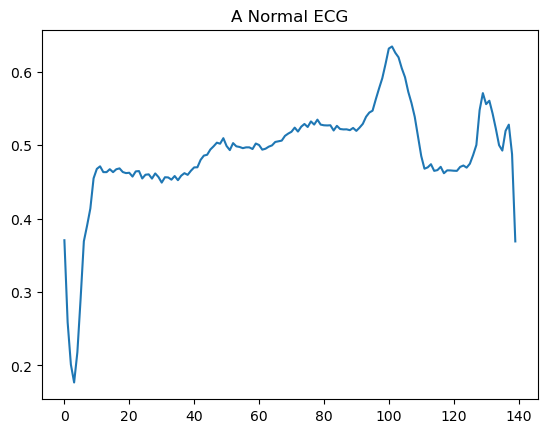

In [33]:
plt.grid()
plt.plot(np.arange(140), normal_train_data[0])
plt.title("A Normal ECG")
plt.show()


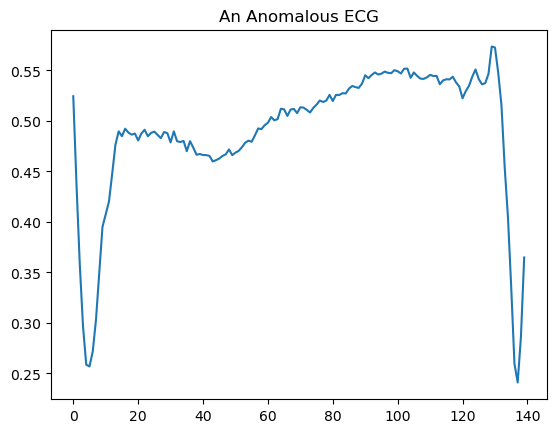

In [34]:
plt.grid()
plt.plot(np.arange(140), anomalous_train_data[0])
plt.title("An Anomalous ECG")
plt.show()

In [13]:
#Model 6
class CNNAnomalyDetector(tf.keras.Model):
    def __init__(self):
        super().__init__()

        # -------- Encoder --------
        self.encoder = tf.keras.Sequential([
            layers.Input(shape=(140, 1)),

            layers.Conv1D(32, 5, strides=2, padding="same"),
            layers.LayerNormalization(),
            layers.PReLU(),
            layers.Dropout(0.1),

            layers.Conv1D(64, 5, strides=2, padding="same"),
            layers.LayerNormalization(),
            layers.PReLU(),
            layers.Dropout(0.15),

            layers.Conv1D(128, 3, strides=2, padding="same"),
            layers.LayerNormalization(),
            layers.PReLU(),
            layers.Dropout(0.15),
        ])

        # -------- Decoder --------
        self.decoder = tf.keras.Sequential([
            layers.Conv1DTranspose(128, 3, strides=2, padding="same"),
            layers.LayerNormalization(),
            layers.PReLU(),
            layers.Dropout(0.1),

            layers.Conv1DTranspose(64, 3, strides=2, padding="same"),
            layers.LayerNormalization(),
            layers.PReLU(),
            layers.Dropout(0.1),

            layers.Conv1DTranspose(32, 3, strides=2, padding="same"),
            layers.LayerNormalization(),
            layers.PReLU(),
            layers.Dropout(0.05),

            layers.Conv1D(1, 3, padding="same", activation="linear"),

            # Final cropping: 144 → 140
            layers.Cropping1D((2, 2))
        ])
    def call(self, x):
        return self.decoder(self.encoder(x))


# -------- Build & compile --------
autoencoder = CNNAnomalyDetector()
autoencoder.compile(optimizer='adam', loss='mae')

# Build model by calling once
_ = autoencoder(tf.zeros((1, 140, 1)))

autoencoder.summary()









Model: "cnn_anomaly_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 18, 128)             │          42,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (1, 140, 1)                 │          94,465 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 136,897 (534.75 KB)

 Trainable params: 136,897 (534.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Callback
callbacks = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


In [15]:
## Train the autoencoder using only normal ECG signals
history = autoencoder.fit(normal_train_data, normal_train_data,
          epochs=40,
          batch_size=512,
          validation_data=(normal_test_data, normal_test_data), 
          shuffle=True,
          callbacks=callbacks
        )

Epoch 1/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.4607 - val_loss: 0.2399
Epoch 2/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.2003 - val_loss: 0.1233
Epoch 3/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1200 - val_loss: 0.0873
Epoch 4/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0729 - val_loss: 0.0696
Epoch 5/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0538 - val_loss: 0.0509
Epoch 6/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0406 - val_loss: 0.0413
Epoch 7/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0336 - val_loss: 0.0300
Epoch 8/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0278 - val_loss: 0.0277
Epoch 9/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0257 - val_loss: 0.0267
Epoch 10/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0239 - val_loss: 0.0207
Epoch 11/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0217 - val_loss: 0.0218
Epoch 12/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0216 - val_loss: 0.0198


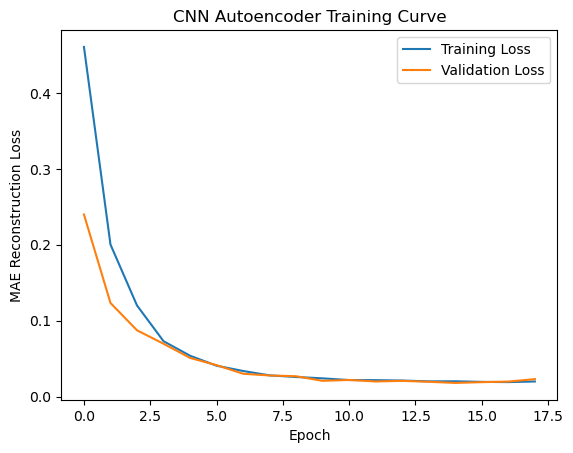

In [16]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MAE Reconstruction Loss")
plt.title("CNN Autoencoder Training Curve")
plt.legend()
plt.show()


In [41]:
encoded_data = autoencoder.encoder(normal_test_data).numpy()
decoded_data = autoencoder.decoder(encoded_data).numpy()


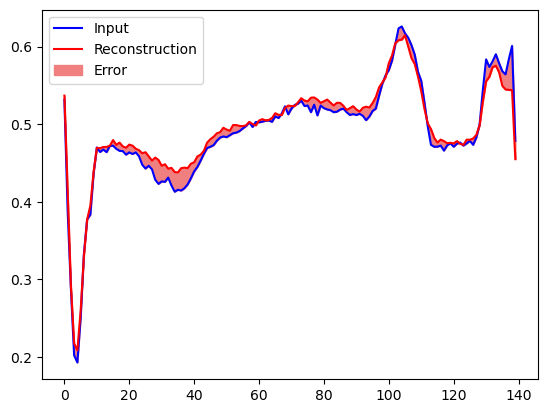

In [18]:
plt.plot(normal_test_data[0], 'b')
plt.plot(decoded_data[0].squeeze(), 'r')

plt.fill_between(
    np.arange(140),
    decoded_data[0].squeeze(),
    normal_test_data[0],
    color='lightcoral'
)

plt.legend(labels=["Input", "Reconstruction", "Error"])
plt.show()


In [40]:
encoded_data = autoencoder.encoder(anomalous_test_data).numpy()
decoded_data = autoencoder.decoder(encoded_data).numpy()


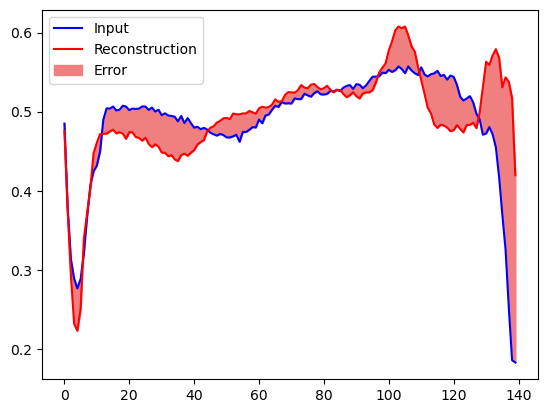

In [20]:
original = anomalous_test_data[0].numpy().squeeze()
recon = decoded_data[0].squeeze()

plt.plot(original, 'b')
plt.plot(recon, 'r')

plt.fill_between(
    np.arange(140),
    recon,
    original,
    color='lightcoral'
)

plt.legend(labels=["Input", "Reconstruction", "Error"])
plt.show()



73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


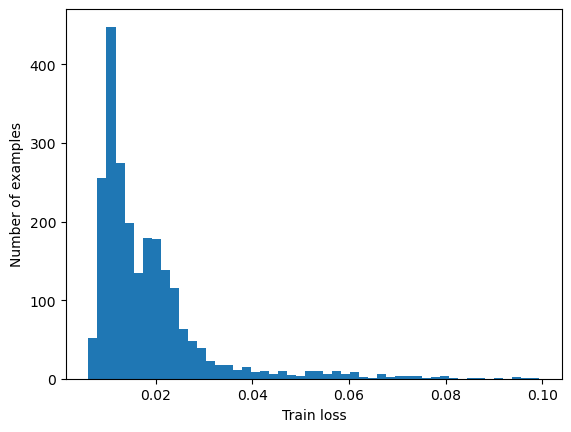

In [21]:
# #Detect anamalies

reconstructions = autoencoder.predict(normal_train_data)

train_loss = tf.reduce_mean(
    tf.abs(reconstructions.squeeze() - normal_train_data),
    axis=1
)

plt.hist(train_loss.numpy(), bins=50)
plt.xlabel("Train loss")
plt.ylabel("Number of examples")
plt.show()



In [22]:
#threshold value 
threshold = np.mean(train_loss) + np.std(train_loss)
print("Threshold: ", threshold)



Threshold:  0.030259497


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


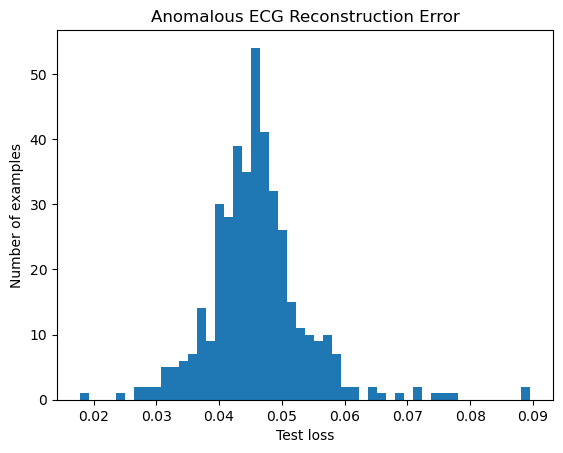

In [30]:
reconstructions = autoencoder.predict(anomalous_test_data).squeeze()

test_loss = tf.reduce_mean(
    tf.abs(reconstructions - anomalous_test_data),
    axis=1
).numpy()

plt.hist(test_loss, bins=50)
plt.xlabel("Test loss")
plt.ylabel("Number of examples")
plt.title("Anomalous ECG Reconstruction Error")
plt.show()

In [23]:
def predict(model, data, threshold):
    reconstructions = model(data)

    # Ensure both tensors have the same shape
    reconstructions = tf.squeeze(reconstructions)
    data = tf.squeeze(data)

    loss = tf.reduce_mean(
        tf.abs(reconstructions - data),
        axis=1
    )

    return (loss > threshold).numpy().astype(int), loss.numpy()
def print_stats(predictions, labels):
    print("Accuracy = {}".format(accuracy_score(labels, predictions)))
    print("Precision = {}".format(precision_score(labels, predictions)))
    print("Recall = {}".format(recall_score(labels, predictions)))


In [24]:
# Predict on test data
preds, scores = predict(autoencoder, test_data, threshold)

# Convert labels to int (CRITICAL)
test_labels = test_labels.astype(int)

# Print metrics
print_stats(preds, test_labels)

Accuracy = 0.945
Precision = 0.8949671772428884
Recall = 0.9831730769230769


In [25]:
## Result

from sklearn.metrics import confusion_matrix

# Ensure labels are integers
test_labels = test_labels.astype(int)

# Compute confusion matrix
cm = confusion_matrix(test_labels, preds)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[536  48]
 [  7 409]]


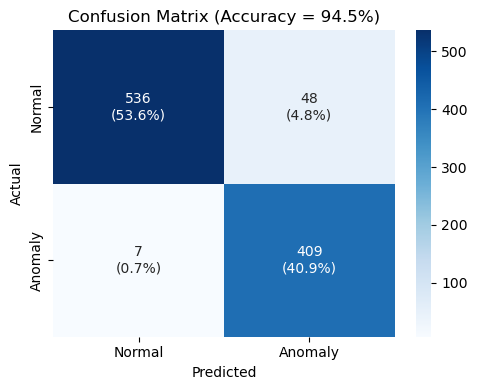

In [29]:
from sklearn.metrics import confusion_matrix


# Ensure labels are integers
test_labels = test_labels.astype(int)

# Compute confusion matrix
cm = confusion_matrix(test_labels, preds)

# Accuracy
accuracy = (cm[0,0] + cm[1,1]) / cm.sum() * 100

# Percentages
cm_percent = cm / cm.sum() * 100

# Build annotation labels (same shape as cm)
labels = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        labels[i, j] = f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)"

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=labels, fmt="", cmap="Blues",
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Accuracy = {accuracy:.1f}%)")
plt.tight_layout()
plt.show()





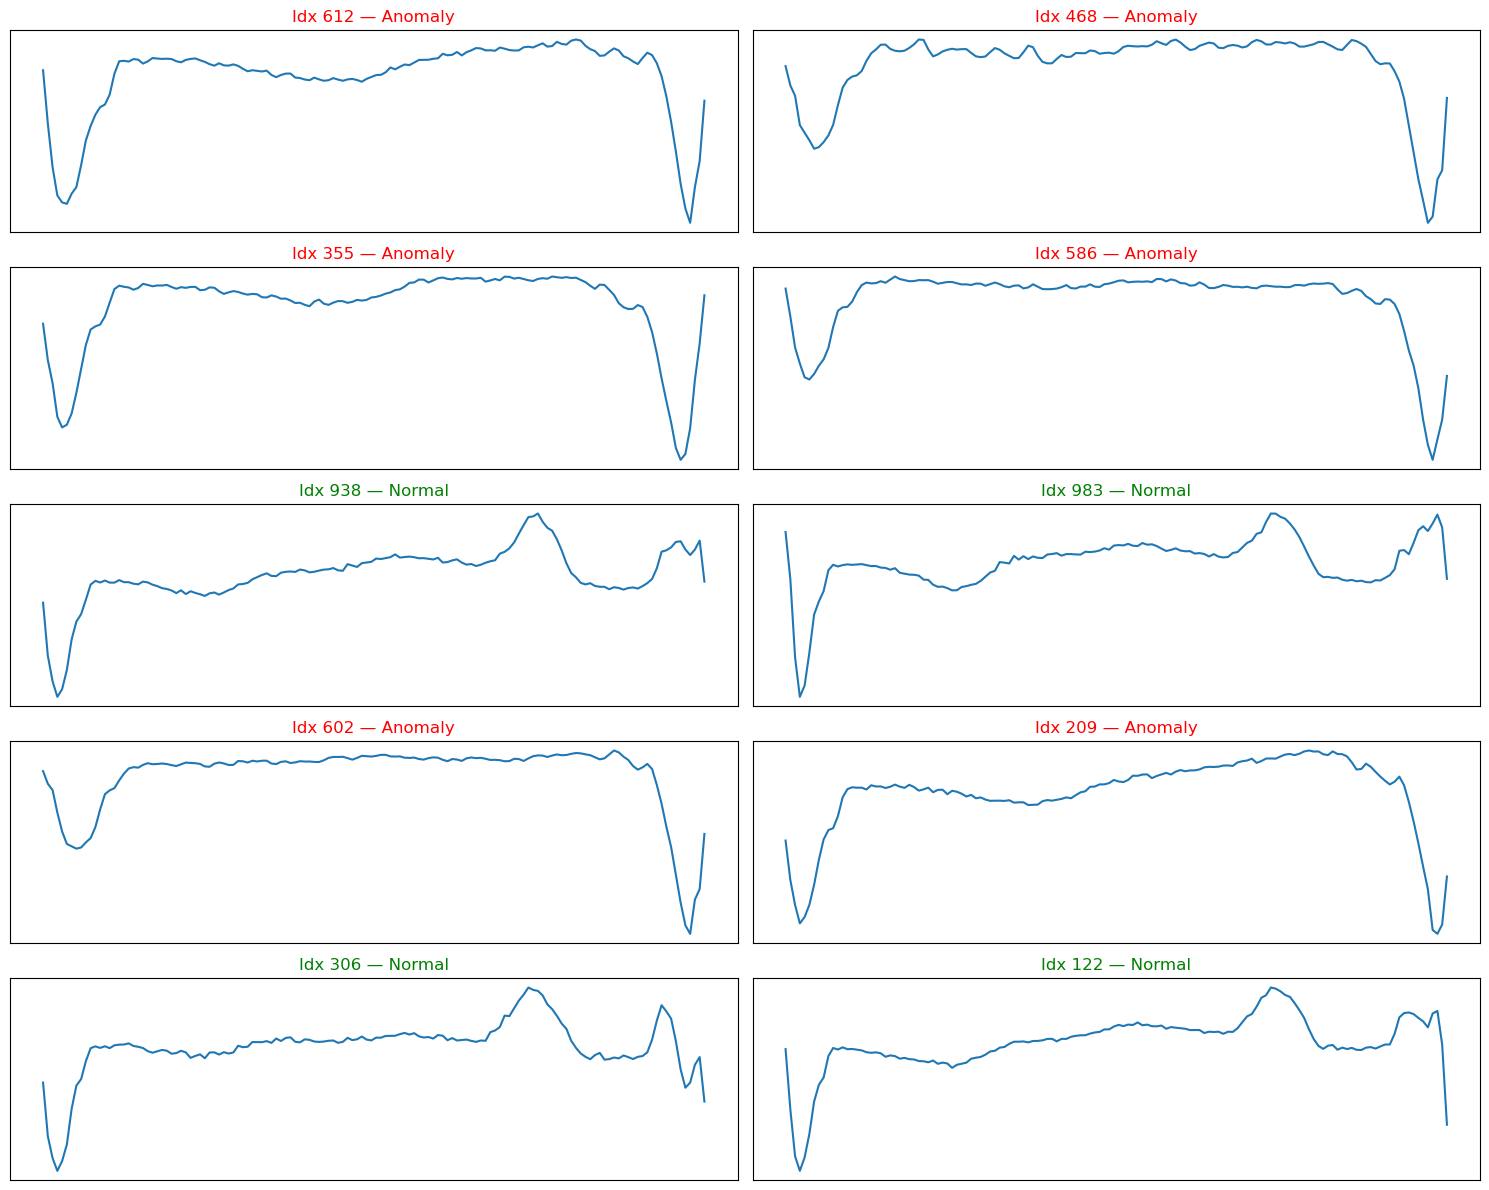

In [39]:
## >> Test prediction by selecting random idx #


indices = np.random.choice(len(test_data), size=10, replace=False)

plt.figure(figsize=(15, 12))

for i, idx in enumerate(indices):
    plt.subplot(5, 2, i + 1)
    plt.plot(test_data[idx])

    label = preds[idx]
    color = "red" if label == 1 else "green"
    plt.title(f"Idx {idx} — {'Anomaly' if label==1 else 'Normal'}", color=color)

    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


